## Подключение библиотек

На первом этапе подключаются основные библиотеки, необходимые для анализа данных и построения модели машинного обучения.

- **pandas** — используется для загрузки и обработки табличных данных.
- **scikit-learn** — библиотека для машинного обучения:
  - `train_test_split` — разделение данных на обучающую и тестовую выборки.
  - `OrdinalEncoder` — кодирование категориальных признаков в числовой формат.
  - `RandomForestClassifier` — модель ансамблевого обучения (случайный лес).
  - `metrics` — вычисление метрик качества модели.

После подключения библиотек можно переходить к загрузке исходных данных.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

## Загрузка исходных данных

На данном этапе формируется список CSV-файлов, содержащих данные исследования.

Файлы загружаются и объединяются в единый DataFrame `df`.
Это позволяет работать со всей совокупностью наблюдений как с одной таблицей.

Результатом выполнения ячейки является общий датасет, содержащий информацию о женщинах и исходах беременности.

In [2]:
files = [
    "../archive/AHS_Woman_08_Rajasthan/AHS_Woman_08_Rajasthan.csv",
    "../archive/AHS_Woman_10_Bihar/AHS_Woman_10_Bihar_Part_1.csv",
    "../archive/AHS_Woman_10_Bihar/AHS_Woman_10_Bihar_Part_2.csv",
    "../archive/AHS_Woman_18_Assam/AHS_Woman_18_Assam.csv",
    "../archive/AHS_Woman_20_Jharkhand/AHS_Woman_20_Jharkhand.csv",
    "../archive/AHS_Woman_21_Odisha/AHS_Woman_21_Odisha.csv",
    "../archive/AHS_Woman_22_Chhattisgarh/AHS_Woman_22_Chhattisgarh.csv",
    "../archive/AHS_Woman_23_Madhya_Pradesh/AHS_Woman_23_Madhya_Pradesh_Part_1.csv",
    "../archive/AHS_Woman_23_Madhya_Pradesh/AHS_Woman_23_Madhya_Pradesh_Part_2.csv"
]

dfs = []

for f in files:
    print("Reading:", f)
    temp = pd.read_csv(f, sep="|", low_memory=False)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Data merged")
print("Dataset shape:", df.shape)

Reading: ../archive/AHS_Woman_08_Rajasthan/AHS_Woman_08_Rajasthan.csv
Reading: ../archive/AHS_Woman_10_Bihar/AHS_Woman_10_Bihar_Part_1.csv
Reading: ../archive/AHS_Woman_10_Bihar/AHS_Woman_10_Bihar_Part_2.csv
Reading: ../archive/AHS_Woman_18_Assam/AHS_Woman_18_Assam.csv
Reading: ../archive/AHS_Woman_20_Jharkhand/AHS_Woman_20_Jharkhand.csv
Reading: ../archive/AHS_Woman_21_Odisha/AHS_Woman_21_Odisha.csv
Reading: ../archive/AHS_Woman_22_Chhattisgarh/AHS_Woman_22_Chhattisgarh.csv
Reading: ../archive/AHS_Woman_23_Madhya_Pradesh/AHS_Woman_23_Madhya_Pradesh_Part_1.csv
Reading: ../archive/AHS_Woman_23_Madhya_Pradesh/AHS_Woman_23_Madhya_Pradesh_Part_2.csv
Data merged
Dataset shape: (8299069, 202)


## Первичный анализ структуры данных

После загрузки данных проводится базовая разведочная проверка (EDA):

1. Вывод списка всех колонок датасета.
2. Просмотр первых строк таблицы (`head()`).
3. Анализ распределения целевой переменной `outcome_pregnancy`.
4. Проверка количества пропущенных значений в каждом столбце.

Этот этап позволяет понять структуру данных и выявить потенциальные проблемы, такие как пропуски или дисбаланс классов.

In [3]:
print("\nColumns:")
print(df.columns)

print("\nFirst rows:")
print(df.head())

print("\nOutcome distribution:")
print(df["outcome_pregnancy"].value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)



Columns:
Index(['w_id', 'hl_id', 'client_w_id', 'state', 'district', 'rural',
       'stratum_code', 'psu_id', 'house_no', 'house_hold_no',
       ...
       'anym', 'respondentname', 'rtelephoneno', 'isnewrecord',
       'recordupdatedcount', 'recordstatus', 'schedule_id', 'year', 'id',
       'v204'],
      dtype='object', length=202)

First rows:
   w_id hl_id  client_w_id  state  district  rural  stratum_code     psu_id  \
0   NaN   NaN          NaN      8        21      1             1  101431218   
1   NaN   NaN          NaN      8        21      1             1  101431169   
2   NaN   NaN          NaN      8        21      1             1  101431095   
3   NaN   NaN          NaN      8        21      1             1  101431064   
4   NaN   NaN          NaN      8        21      1             1  101431121   

   house_no  house_hold_no  ...  anym  respondentname  rtelephoneno  \
0        24              2  ...   NaN             NaN           NaN   
1        25              1  ..

## Очистка и подготовка целевой переменной

Целевая переменная `outcome_pregnancy` приводится к числовому типу данных.

Далее выполняется очистка выборки:
- удаляются строки с отсутствующим значением целевой переменной;
- оставляются только наблюдения с корректными значениями классов (1 и 2).

Таким образом формируется корректная выборка для задачи классификации.

In [4]:
df["outcome_pregnancy"] = pd.to_numeric(df["outcome_pregnancy"], errors="coerce")

df = df.dropna(subset=["outcome_pregnancy"])

df = df[df["outcome_pregnancy"].isin([1, 2])]

print("Cleaned target distribution:")
print(df["outcome_pregnancy"].value_counts())

Cleaned target distribution:
outcome_pregnancy
2.0    6118029
1.0    1323024
Name: count, dtype: int64


## Удаление признаков с большим количеством пропусков

Для каждого признака рассчитывается доля пропущенных значений.

Если доля пропусков превышает **90%**, такой признак считается нерелевантным и удаляется из датасета.

Это позволяет:
- уменьшить размерность данных;
- избавиться от признаков, которые не содержат полезной информации.

In [5]:
missing_ratio = df.isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > 0.9].index

print("Columns to drop:", len(cols_to_drop))

df = df.drop(columns=cols_to_drop)

print("Dataset shape after dropping columns:", df.shape)

Columns to drop: 33
Dataset shape after dropping columns: (7441053, 169)


## Удаление служебных идентификаторов

Из датасета удаляются столбцы, содержащие уникальные идентификаторы записей:

- `w_id`
- `hl_id`
- `client_w_id`
- `id`
- `psu_id`

Такие признаки не несут информации для прогнозирования и могут ухудшать качество модели, поэтому они исключаются из анализа.

In [6]:
id_cols = [
    "w_id",
    "hl_id",
    "client_w_id",
    "id",
    "psu_id"
]

df = df.drop(columns=[c for c in id_cols if c in df.columns])

print("Dataset shape after removing IDs:", df.shape)

Dataset shape after removing IDs: (7441053, 164)


## Снижение размера датасета

Для ускорения обучения модели из исходного набора данных выбирается подвыборка размером **50 000 наблюдений**.

Используется стратифицированная выборка (`stratify`), чтобы сохранить исходное распределение классов целевой переменной.

Это позволяет уменьшить вычислительную нагрузку без значительной потери информации.

In [7]:
# Снижение размера датасета с учетом географического распределения

print("Исходный размер датасета:", len(df))
print("Исходное распределение по штатам:")
print(df['state'].value_counts())

# Создаем стратификационную колонку (штат + исход)
df['_stratify'] = df['state'].astype(str) + '_' + df['outcome_pregnancy'].astype(str)

# Стратифицированная выборка
df, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df['_stratify'],
    random_state=42
)

# Удаляем временную колонку
df = df.drop(columns=['_stratify'])

print("\nРазмер после выборки:", len(df))
print("\nРаспределение по штатам после выборки:")
state_dist = df['state'].value_counts()
print(state_dist)
print(f"\nКоличество штатов в выборке: {len(state_dist)}")


Исходный размер датасета: 7441053
Исходное распределение по штатам:
state
10    1527097
23    1234197
20    1075369
21    1063029
18     933699
8      901580
22     706082
Name: count, dtype: int64

Размер после выборки: 50000

Распределение по штатам после выборки:
state
10    10261
23     8293
20     7226
21     7143
18     6274
8      6058
22     4745
Name: count, dtype: int64

Количество штатов в выборке: 7


## Определение числовых и категориальных признаков

На данном этапе признаки разделяются на две группы:

- **Числовые признаки** (`num_cols`)
- **Категориальные признаки** (`cat_cols`)

Целевая переменная `outcome_pregnancy` исключается из списка признаков.

Такое разделение необходимо для дальнейшей корректной обработки пропусков и кодирования категориальных данных.

In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

if "outcome_pregnancy" in num_cols:
    num_cols = num_cols.drop("outcome_pregnancy")

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 23
Categorical columns: 140


## Заполнение пропущенных значений

Пропуски обрабатываются отдельно для разных типов данных:

- для **числовых признаков** пропущенные значения заменяются медианой;
- для **категориальных признаков** используется специальная категория `"Unknown"`.

После выполнения операции проверяется, что в датасете больше нет пропущенных значений.

In [9]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))

df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## Формирование матрицы признаков и целевой переменной

Датасет разделяется на:

- **X** — матрицу признаков
- **y** — целевую переменную `outcome_pregnancy`

Данный формат является стандартным для обучения моделей в библиотеке scikit-learn.

In [10]:
X = df.drop(columns=["outcome_pregnancy"])
y = df["outcome_pregnancy"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 163)
y shape: (50000,)


## Разделение данных на обучающую и тестовую выборки

Данные разделяются в пропорции **80/20**:

- **обучающая выборка (train)** — используется для обучения модели;
- **тестовая выборка (test)** — используется для оценки качества модели.

Разделение выполняется стратифицированно по целевой переменной, чтобы сохранить баланс классов.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


In [16]:
from catboost import CatBoostClassifier
import time

# Категориальные признаки
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Очищаем данные: все категориальные колонки приводим к строкам
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
X_train_clean[cat_cols] = X_train_clean[cat_cols].astype(str)
X_test_clean[cat_cols] = X_test_clean[cat_cols].astype(str)

# Теперь создаём модель
model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    cat_features=cat_cols,
    verbose=100,
    random_seed=42,
    thread_count=-1,          # ускорение
    early_stopping_rounds=50
)

# Обучаем на ОЧИЩЕННЫХ данных
start = time.time()
model.fit(X_train_clean, y_train)   # ← здесь X_train_clean, а не X_train
train_time = time.time() - start
print(f"Время обучения: {train_time:.2f} сек")

# Предсказание – тоже на очищенных тестовых
y_pred = model.predict(X_test_clean)

0:	learn: 0.5863346	total: 320ms	remaining: 1m 35s
100:	learn: 0.0742746	total: 18.2s	remaining: 35.9s
200:	learn: 0.0676739	total: 34.8s	remaining: 17.2s
299:	learn: 0.0645418	total: 52.5s	remaining: 0us
Время обучения: 53.59 сек


In [17]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

# Предсказание на тестовой выборке
y_pred = model.predict(X_test_clean)
y_proba = model.predict_proba(X_test_clean)[:, 1]

# Метрики
print("=== Оценка модели на тестовой выборке ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Важность признаков (топ-10)
import pandas as pd
feature_importance = model.get_feature_importance()
feature_names = X_train_clean.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)
print("\nТоп-10 важнейших признаков:")
print(importance_df)

=== Оценка модели на тестовой выборке ===
Accuracy: 0.9757
ROC-AUC: 0.9876

Classification Report:
              precision    recall  f1-score   support

         1.0       0.97      0.89      0.93      1778
         2.0       0.98      0.99      0.99      8222

    accuracy                           0.98     10000
   macro avg       0.97      0.94      0.96     10000
weighted avg       0.98      0.98      0.98     10000


Confusion Matrix:
[[1584  194]
 [  49 8173]]

Топ-10 важнейших признаков:
                        feature  importance
22                 last_preg_no   30.529154
136  is_husband_living_with_you   13.891047
60         anm_in_last_3_months   11.350899
67           twsi_expall_status    4.387353
84             year_of_marriage    4.140621
45    is_currently_menstruating    3.729277
79                year_of_birth    2.417498
12                          age    2.210935
159          recordupdatedcount    1.912516
162                        year    1.622034


In [ ]:
# Сравнение распределения реальных и предсказанных классов
print("\n=== Сравнение распределения исходов ===")
print("Реальное распределение в тестовой выборке:")
print(y_test.value_counts(normalize=True))
print("\nПредсказанное распределение:") 
print(pd.Series(y_pred).value_counts(normalize=True))


=== Сравнение распределения исходов ===
Реальное распределение в тестовой выборке:
outcome_pregnancy
2.0    0.8222
1.0    0.1778
Name: proportion, dtype: float64

Предсказанное распределение:
2.0    0.8367
1.0    0.1633
Name: proportion, dtype: float64


In [19]:
sample_sizes = [10000, 20000, 30000, 40000]  # до 40000 (максимум)
times_vs_size = []

for size in sample_sizes:
    # Случайная подвыборка строк без разделения на train/test
    X_sample = X_train_clean.sample(n=size, random_state=42)
    y_sample = y_train.loc[X_sample.index]  # соответствующие метки
    
    model_tmp = CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        cat_features=cat_cols, verbose=False, random_seed=42, thread_count=-1
    )
    start = time.time()
    model_tmp.fit(X_sample, y_sample)
    elapsed = time.time() - start
    times_vs_size.append(elapsed)
    print(f"Размер {size}: {elapsed:.2f} сек")

# Вывод таблицы
print("\nРазмер\tВремя (сек)")
for s, t in zip(sample_sizes, times_vs_size):
    print(f"{s}\t{t:.2f}")

Размер 10000: 23.81 сек
Размер 20000: 34.75 сек
Размер 30000: 45.80 сек
Размер 40000: 55.50 сек

Размер	Время (сек)
10000	23.81
20000	34.75
30000	45.80
40000	55.50


In [20]:
thread_counts = [1, 2, 4, 8]
times_vs_threads = []

for thr in thread_counts:
    model_tmp = CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        cat_features=cat_cols, verbose=False, random_seed=42, thread_count=thr
    )
    start = time.time()
    model_tmp.fit(X_train_clean, y_train)
    elapsed = time.time() - start
    times_vs_threads.append(elapsed)
    print(f"threads={thr}: {elapsed:.2f} сек")

threads=1: 354.36 сек
threads=2: 184.86 сек
threads=4: 100.09 сек
threads=8: 56.43 сек


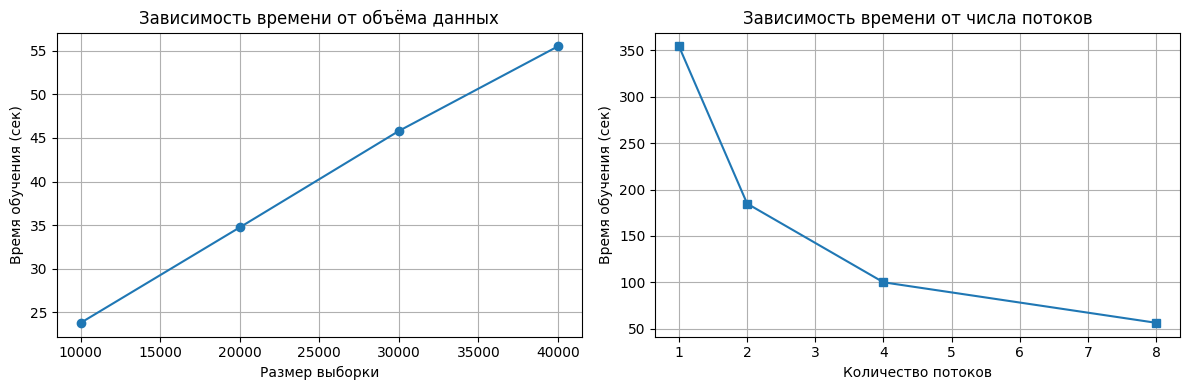

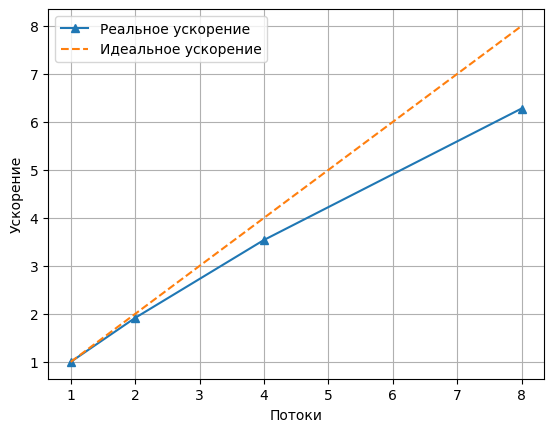

In [21]:
import matplotlib.pyplot as plt

# График времени от объёма данных
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(sample_sizes, times_vs_size, marker='o')
plt.xlabel('Размер выборки')
plt.ylabel('Время обучения (сек)')
plt.title('Зависимость времени от объёма данных')
plt.grid(True)

# График времени от числа потоков
plt.subplot(1,2,2)
plt.plot(thread_counts, times_vs_threads, marker='s')
plt.xlabel('Количество потоков')
plt.ylabel('Время обучения (сек)')
plt.title('Зависимость времени от числа потоков')
plt.grid(True)
plt.tight_layout()
plt.show()

# График ускорения
speedup = [times_vs_threads[0]/t for t in times_vs_threads]
plt.plot(thread_counts, speedup, marker='^', label='Реальное ускорение')
plt.plot(thread_counts, thread_counts, '--', label='Идеальное ускорение')
plt.xlabel('Потоки')
plt.ylabel('Ускорение')
plt.legend()
plt.grid(True)
plt.show()